**Bike Sharing Linear Regression**



Maxine Somers, Emilio Wagner Munguia, Connor Tate

**Loading the data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/My Drive/Colab Notebooks/Data/day.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
day_data = pd.read_csv(path)

# Number of samples and features
num_samples, num_features = day_data.shape
print("Number of Samples:", num_samples)
print("Number of Features:", num_features, '\n')

# Feature names
feature_names = list(day_data.columns)
print("Feature names: ", feature_names, '\n')

# Data types
print("Data Types:")
print(day_data.dtypes)


Number of Samples: 731
Number of Features: 16 

Feature names:  ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt'] 

Data Types:
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


**Data Cleaning and preprocessing**



In [ ]:
# Count of any null values
print("Null values in each column:")
print(day_data.isnull().sum(), "\n")

day_data_clean = day_data.dropna()

print("Clean data and original data are equal: ", day_data.equals(day_data_clean), "\n")

Null values in each column:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64 

Clean data and original data are equal:  True 



Since the dataset was already clean and complete, we decided to make no adjustments to the data before continuing.

For irrelevant/identifier features we chose the following:



*   **instant**: It's just an id value used in the data, no value for our analysis.
*   **dteday**: Given that we already have year, month, and whether it's a working day, we don't really need the specific date.
*   **atemp**: Since atemp (feels like) is a combination of other factors we already have, including temp, hum, windspeed, we don't feel the need to keep this feature.

To avoid data leakage, we removed both the **casual** and **registered** features since their sum gives the output label **cnt**. Our model would just take the sum of these columns, avoiding analysis of the features we actually care about.

We remove working day because if it is a weekday and not a holiday then it is a workingday.

We remove season because it's not relevant, month tracks the same and is more specific

In [ ]:
# Removing irrelevant and identifier features
day_data_clean = day_data_clean.drop(columns=["instant", "dteday", "atemp", "season", "workingday"])

# Removing features to avoid data leakage
day_data_clean = day_data_clean.drop(columns=["casual", "registered"])
print(day_data_clean.columns, "\n")

# Overview of our data thus far
print(day_data_clean.describe())

Index(['yr', 'mnth', 'holiday', 'weekday', 'weathersit', 'temp', 'hum',
       'windspeed', 'cnt'],
      dtype='object') 

               yr        mnth     holiday     weekday  weathersit        temp  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.500684    6.519836    0.028728    2.997264    1.395349    0.495385   
std      0.500342    3.451913    0.167155    2.004787    0.544894    0.183051   
min      0.000000    1.000000    0.000000    0.000000    1.000000    0.059130   
25%      0.000000    4.000000    0.000000    1.000000    1.000000    0.337083   
50%      1.000000    7.000000    0.000000    3.000000    1.000000    0.498333   
75%      1.000000   10.000000    0.000000    5.000000    2.000000    0.655417   
max      1.000000   12.000000    1.000000    6.000000    3.000000    0.861667   

              hum   windspeed          cnt  
count  731.000000  731.000000   731.000000  
mean     0.627894    0.190486  4504.348837  
std      0.

In this dataset, the continuous values (temp, hum, windspeed) were already normalized according to the README, so we made no further adjustments.



For our categorial features, we chose the following: **mnth**, **weekday**, **weathersit**. All of these features are discrete, non-binary numbers, and their values would not be meaningful as-is (for example, a month of 1 vs 12 has a large difference despite January and December being rather similar). For this reason, we decided to use one-hot encoding to make them more suitable for linear regression.

In [ ]:
cat_cols = ["mnth", "weekday", "weathersit"]
day_data_clean = pd.get_dummies(day_data_clean, columns=cat_cols)

# List of columns after one-hot encoding
print(day_data_clean.columns, '\n')
print("Number of features: ", len(day_data_clean.columns))

Index(['yr', 'holiday', 'temp', 'hum', 'windspeed', 'cnt', 'mnth_1', 'mnth_2',
       'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9',
       'mnth_10', 'mnth_11', 'mnth_12', 'weekday_0', 'weekday_1', 'weekday_2',
       'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_1',
       'weathersit_2', 'weathersit_3'],
      dtype='object') 

Number of features:  28


**Data visualization and exploratory analysis**


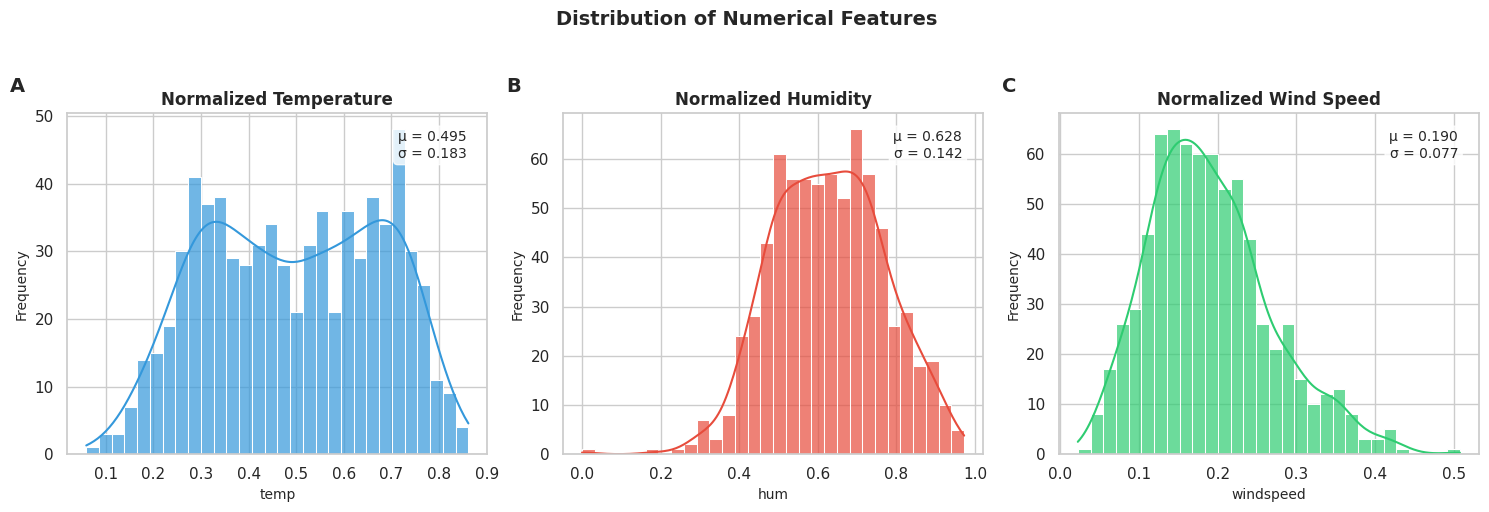

In [ ]:
  sns.set_theme(style="whitegrid")

  num_features = ["temp", "hum", "windspeed"]
  feature_labels = {
      "temp": "Normalized Temperature",
      "hum": "Normalized Humidity",
      "windspeed": "Normalized Wind Speed"
  }
  colors = ['#3498db', '#e74c3c', '#2ecc71']
  panel_labels = ['A', 'B', 'C']

  fig, axes = plt.subplots(1, 3, figsize=(15, 5))

  for i, col in enumerate(num_features):
      sns.histplot(day_data[col], bins=30, kde=True, color=colors[i],
                    edgecolor='white', alpha=0.7, ax=axes[i])
      axes[i].set_title(feature_labels[col], fontsize=12, fontweight='bold')
      axes[i].set_xlabel(col, fontsize=10)
      axes[i].set_ylabel("Frequency", fontsize=10)
      # Add panel label
      axes[i].text(-0.1, 1.05, panel_labels[i], transform=axes[i].transAxes,
                    fontsize=14, fontweight='bold', va='bottom', ha='right')
      # Add mean and std
      mean_val = day_data[col].mean()
      std_val = day_data[col].std()
      stats_text = f'μ = {mean_val:.3f}\nσ = {std_val:.3f}'
      axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes,
                    fontsize=10, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

  fig.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.02)
  plt.tight_layout()
  # plt.savefig("visualizations/numerical_features_distribution.png", dpi=150, bbox_inches='tight')
  plt.show()

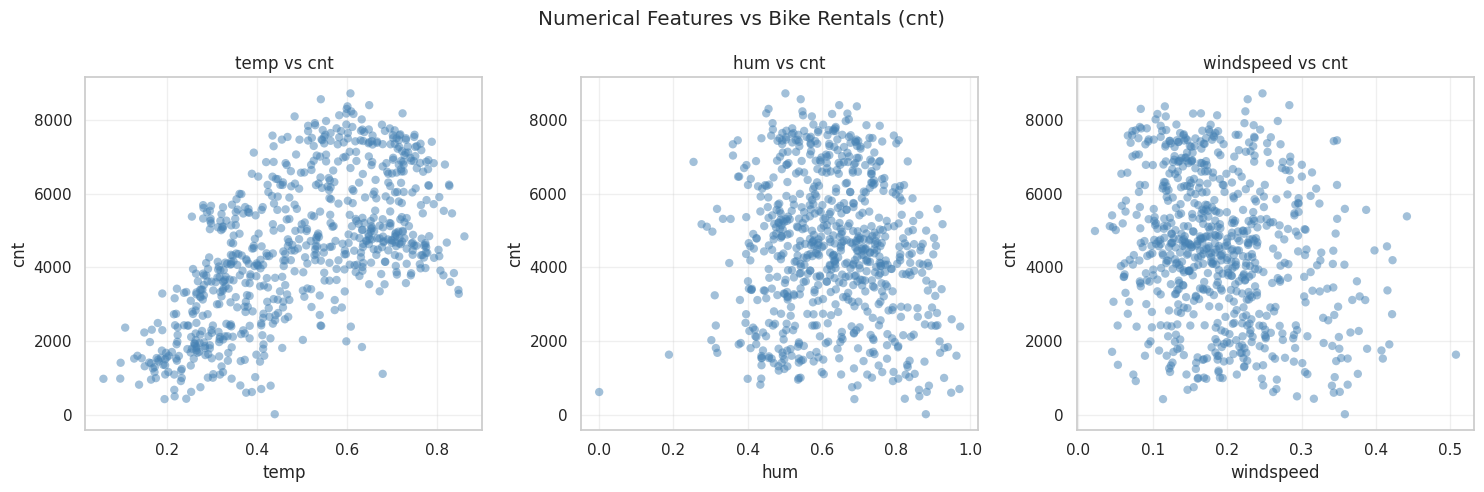

In [ ]:
#Scatter plots of numerical features
num_cols = ["temp", "hum", "windspeed"]
target = "cnt"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Numerical Features vs Bike Rentals (cnt)")

for idx, col in enumerate(num_cols):
        ax = axes[idx]
        ax.scatter(day_data[col], day_data[target], alpha=0.5, color='steelblue', edgecolor='none')
        ax.set_xlabel(col)
        ax.set_ylabel(target)
        ax.set_title(f"{col} vs {target}")
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("scatter_numerical_vs_target.png", dpi=150)
plt.show()

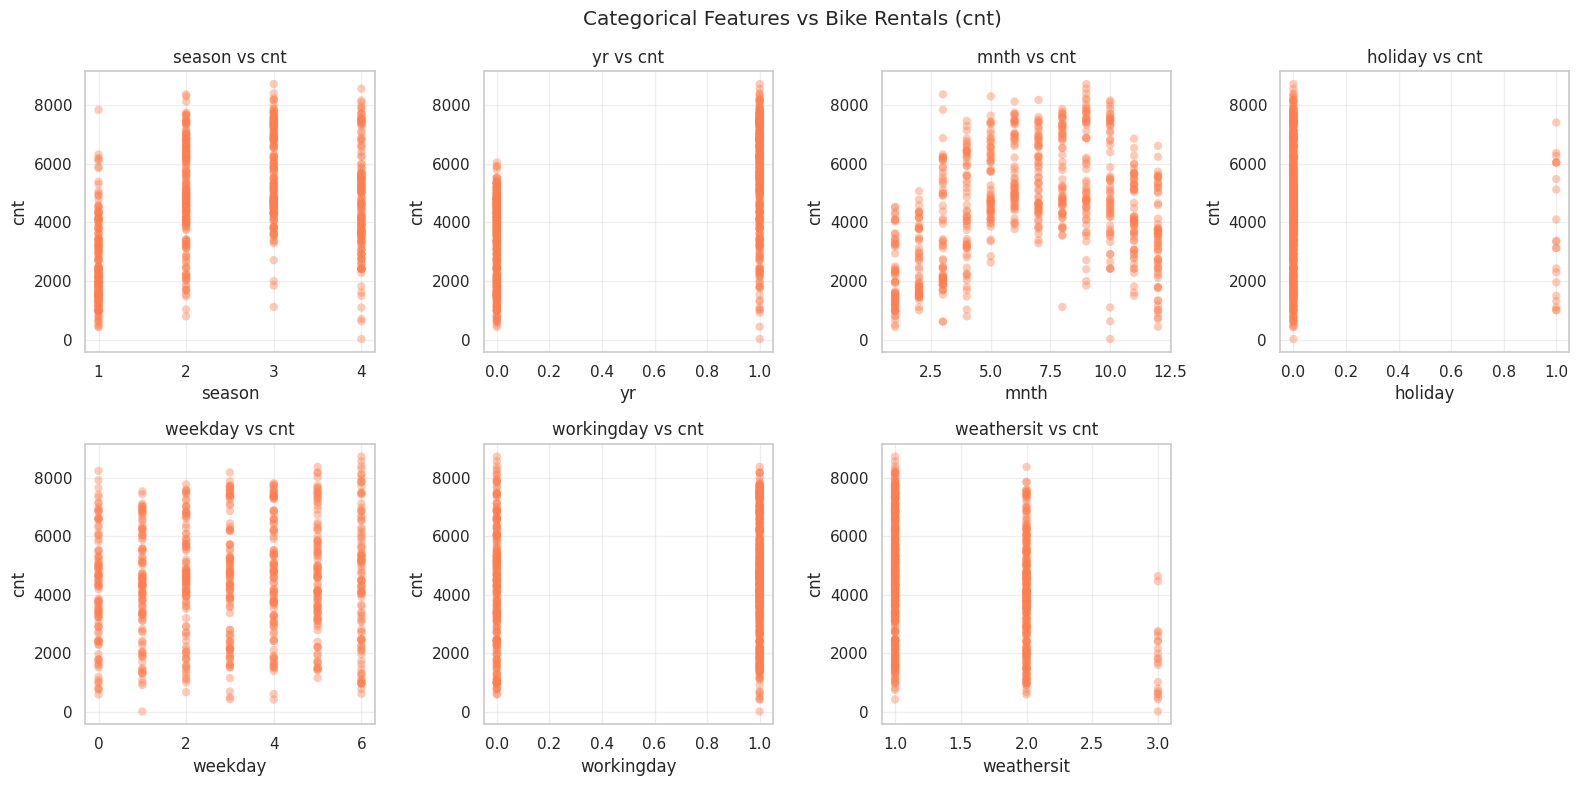

In [ ]:
#Scatter plots of categorical features
cat_cols = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
target = "cnt"

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Categorical Features vs Bike Rentals (cnt)")

for idx, col in enumerate(cat_cols):
        ax = axes[idx // 4, idx % 4]
        ax.scatter(day_data[col], day_data[target], alpha=0.4, color='coral', edgecolor='none')
        ax.set_xlabel(col)
        ax.set_ylabel(target)
        ax.set_title(f"{col} vs {target}")
        ax.grid(alpha=0.3)

axes[1, 3].set_visible(False)

plt.tight_layout()
plt.savefig("scatter_categorical_vs_target.png", dpi=150)
plt.show()

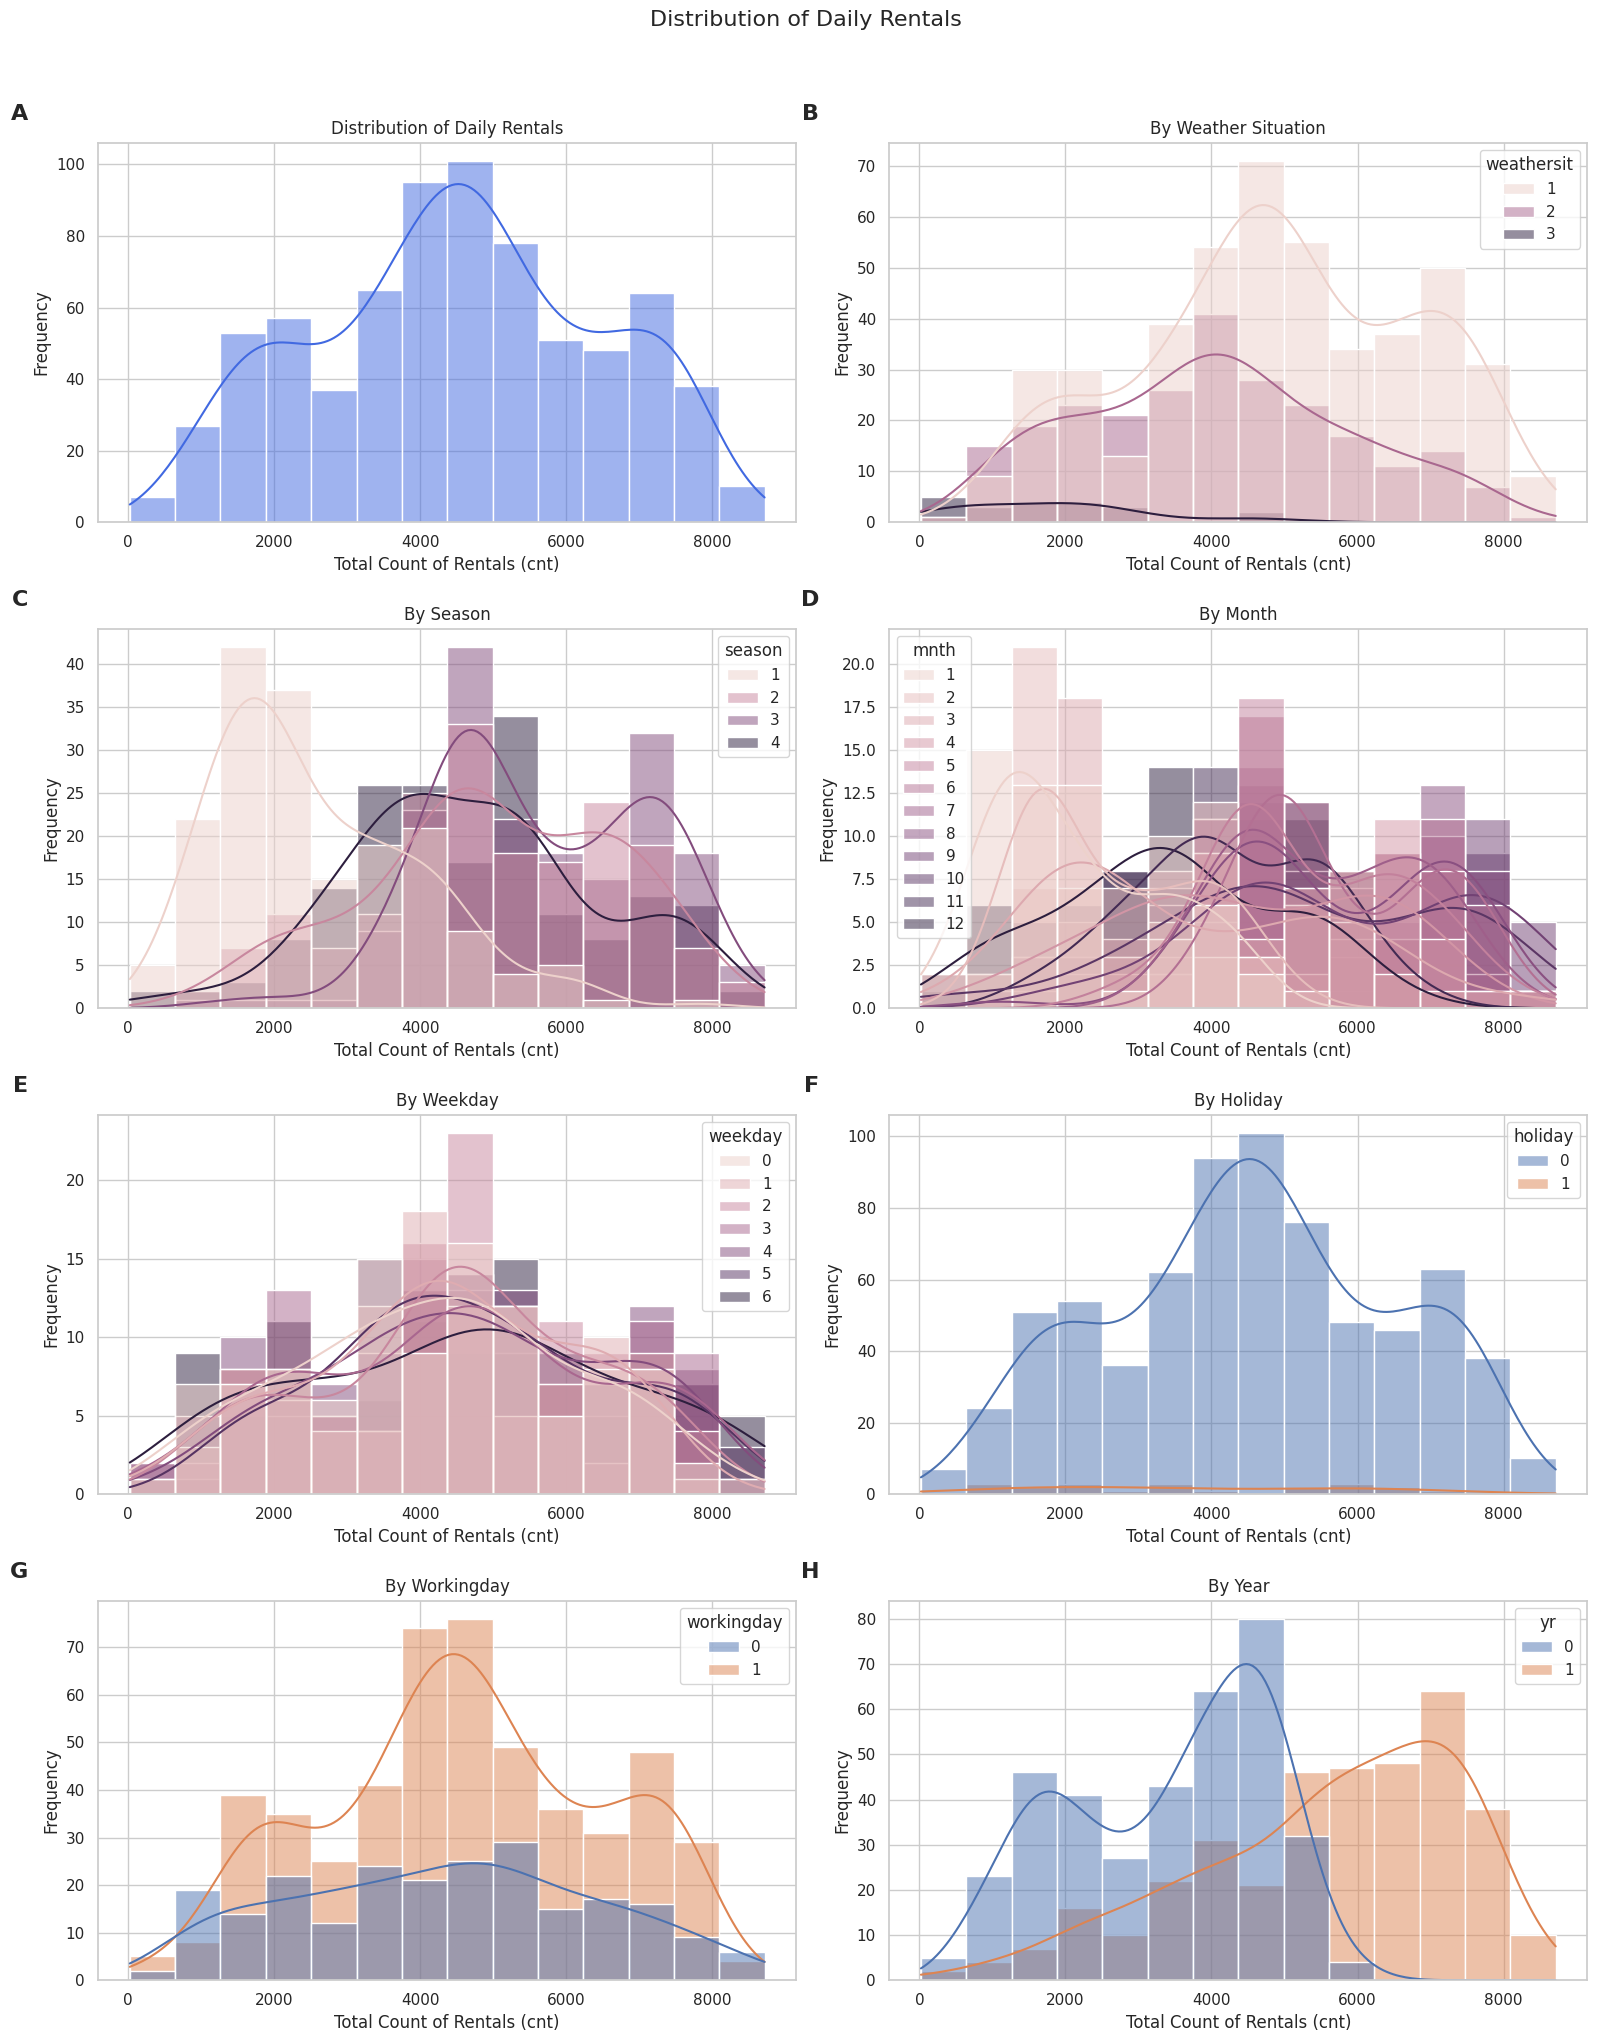

In [ ]:
    # Set the visual style
    sns.set_theme(style="whitegrid")

    # Create a figure with 4 rows and 2 columns of subplots
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))

    # Panel labels for paper references
    panel_labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

    # Plot the distribution of the target variable 'cnt'
    sns.histplot(x=day_data['cnt'], kde=True, color='royalblue', ax=axes[0, 0])
    axes[0, 0].set_title('Distribution of Daily Rentals', fontsize=12)
    axes[0, 0].set_xlabel('Total Count of Rentals (cnt)')
    axes[0, 0].set_ylabel('Frequency')

    # Plot by weather situation
    sns.histplot(data=day_data, x='cnt', hue='weathersit', kde=True, ax=axes[0, 1])
    axes[0, 1].set_title('By Weather Situation', fontsize=12)
    axes[0, 1].set_xlabel('Total Count of Rentals (cnt)')
    axes[0, 1].set_ylabel('Frequency')

    # Plot by season
    sns.histplot(data=day_data, x='cnt', hue='season', kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('By Season', fontsize=12)
    axes[1, 0].set_xlabel('Total Count of Rentals (cnt)')
    axes[1, 0].set_ylabel('Frequency')

    # Plot by month
    sns.histplot(data=day_data, x='cnt', hue='mnth', kde=True, ax=axes[1, 1])
    axes[1, 1].set_title('By Month', fontsize=12)
    axes[1, 1].set_xlabel('Total Count of Rentals (cnt)')
    axes[1, 1].set_ylabel('Frequency')

    # Plot by weekday
    sns.histplot(data=day_data, x='cnt', hue='weekday', kde=True, ax=axes[2, 0])
    axes[2, 0].set_title('By Weekday', fontsize=12)
    axes[2, 0].set_xlabel('Total Count of Rentals (cnt)')
    axes[2, 0].set_ylabel('Frequency')

    # Plot by holiday
    sns.histplot(data=day_data, x='cnt', hue='holiday', kde=True, ax=axes[2, 1])
    axes[2, 1].set_title('By Holiday', fontsize=12)
    axes[2, 1].set_xlabel('Total Count of Rentals (cnt)')
    axes[2, 1].set_ylabel('Frequency')

    # Plot by workingday
    sns.histplot(data=day_data, x='cnt', hue='workingday', kde=True, ax=axes[3, 0])
    axes[3, 0].set_title('By Workingday', fontsize=12)
    axes[3, 0].set_xlabel('Total Count of Rentals (cnt)')
    axes[3, 0].set_ylabel('Frequency')

    # Plot by year
    sns.histplot(data=day_data, x='cnt', hue='yr', kde=True, ax=axes[3, 1])
    axes[3, 1].set_title('By Year', fontsize=12)
    axes[3, 1].set_xlabel('Total Count of Rentals (cnt)')
    axes[3, 1].set_ylabel('Frequency')

    # Add panel labels (A, B, C, D, E, F, G, H) to each subplot
    for idx, ax in enumerate(axes.flat):
        ax.text(-0.1, 1.05, panel_labels[idx], transform=ax.transAxes,
                fontsize=16, fontweight='bold', va='bottom', ha='right')

    plt.suptitle('Distribution of Daily Rentals', fontsize=16, y=1.02)
    plt.tight_layout()
    # plt.show()

**Model implementation**



In [ ]:
class LinearRegression:
    def __init__(self, add_bias=True):
        self.add_bias = add_bias
        self.w = None

    def fit(self, x, y):
        if x.ndim == 1:
            x = x[:, None]

        if self.add_bias:
            x = np.column_stack([x, np.ones(x.shape[0])])

        self.w = np.linalg.lstsq(x, y, rcond=None)[0]
        return self

    def predict(self, x):
        if x.ndim == 1:
            x = x[:, None]

        if self.add_bias:
            x = np.column_stack([x, np.ones(x.shape[0])])

        return x @ self.w

In the implementation above, linear regression is trained using the closed-form least squares solution. During training (fit), the input features are first reshaped if needed, and a column of ones is optionally added to account for the bias (intercept) term. The model then uses np.linalg.lstsq to compute the weight vector that best fits the training data by minimizing the squared prediction error.

The learned weight vector contains one weight per feature (and one additional weight for the bias, if enabled).

During prediction (predict), the same feature formatting is applied to the input data, and predictions are computed as a simple matrix multiplication between the input matrix and the learned weights.

**Train/test split**


In [ ]:
# Separate input features (X) and target variable (y)
# X contains all numerical features except the target "cnt"
# y contains the total number of bike rentals we want to predict
X = day_data_clean.drop("cnt", axis=1).to_numpy(dtype=float)
y = day_data_clean["cnt"].to_numpy(dtype=float)


# Shuffle the dataset to remove any ordering effects (e.g., time-based patterns)
# Using a fixed random_state ensures the same train/test split every run
shuffled = day_data_clean.sample(frac=1, random_state=54)

# Split index for an 80/20 train-test split
split_idx = int(len(shuffled) * 0.8)

# Split the shuffled data into training and test sets
train = shuffled.iloc[:split_idx]
test = shuffled.iloc[split_idx:]

# Extract features and targets for training
X_train = train.drop(columns=['cnt']).values.astype(float)
y_train = train['cnt'].values.astype(float)

# Extract features and targets for testing
X_test = test.drop(columns=['cnt']).values.astype(float)
y_test = test['cnt'].values.astype(float)

# Train the linear regression model using only the training data
# add_bias=True automatically adds a column of ones for the intercept term
model = LinearRegression(add_bias=True)
model.fit(X_train, y_train)

# Confirm training and inspect the learned parameter vector
print("Model trained.")
print("Number of learned weights (including bias):", model.w.shape[0])


Model trained.
Number of learned weights (including bias): 28


This code prepares the dataset for supervised learning by separating input features (X) from the target variable (y), then randomly splitting the data into training and test sets. A fixed random seed is used so that the split is reproducible. The linear regression model is trained only on the training data, and the test set is held out for final evaluation.




**Evaluation metric**



In [ ]:
def mse(y, y_hat):
    return np.mean((y - y_hat) ** 2)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

mse_train = mse(y_train, y_train_pred)
mse_test = mse(y_test, y_test_pred)

print("Training MSE:", mse_train)
print("Test MSE:", mse_test)

Training MSE: 650464.4743907985
Test MSE: 628522.9337642912


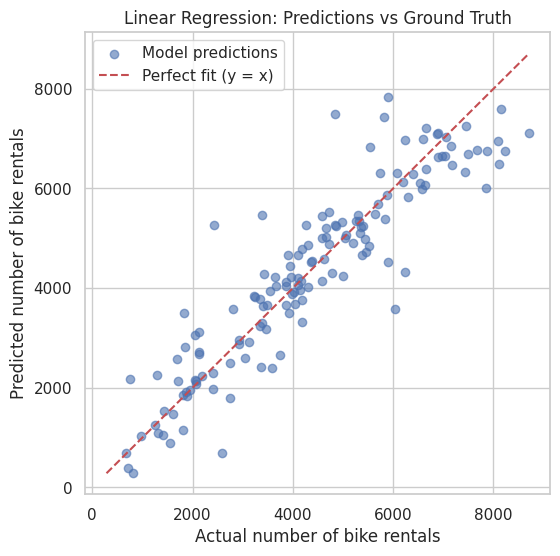

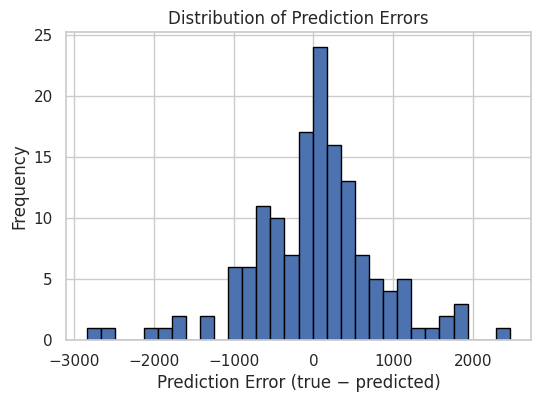

In [ ]:
plt.figure(figsize=(6, 6))

# Scatter plot: predicted vs actual values
plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.6,
    label="Model predictions"
)

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    color="r",
    label="Perfect fit (y = x)"
)

plt.xlabel("Actual number of bike rentals")
plt.ylabel("Predicted number of bike rentals")
plt.title("Linear Regression: Predictions vs Ground Truth")
plt.legend()
plt.grid(True)
plt.show()



errors = y_test - y_test_pred

plt.figure(figsize=(6, 4))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel("Prediction Error (true − predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()


**Feature engineering**

**Model retraining and analysis**

In [ ]:
def test_feature_impact(df, feature_name, baseline_train=None, baseline_test=None):
    """
    1. Trains model on df.
    2. Calculates both Train and Test MSE.
    3. Plots: Train/Test Comparison, Actual vs Predicted, Residuals.
    """
    # --- 1. Prepare Data ---
    X = df.drop(columns=['cnt']).values.astype(float)
    y = df['cnt'].values.astype(float)

    # --- 2. Split (Fixed random_state for fair comparison) ---
    shuffled = df.sample(frac=1, random_state=54)
    split_idx = int(len(shuffled) * 0.8)

    train = shuffled.iloc[:split_idx]
    test = shuffled.iloc[split_idx:]

    X_train = train.drop(columns=['cnt']).values.astype(float)
    y_train = train['cnt'].values.astype(float)
    X_test = test.drop(columns=['cnt']).values.astype(float)
    y_test = test['cnt'].values.astype(float)

    # --- 3. Train Model ---
    model = LinearRegression()
    model.fit(X_train, y_train)

    # --- 4. Predictions & Metrics ---
    # Train Metrics
    y_pred_train = model.predict(X_train)
    mse_train = mse(y_train, y_pred_train)

    # Test Metrics
    y_pred_test = model.predict(X_test)
    mse_test = mse(y_test, y_pred_test)

    residuals = y_test - y_pred_test

    # 5. Print Report
    print(f"--- Results for: {feature_name} ---")
    print(f"Training MSE: {mse_train:.4f}")
    print(f"Test MSE:     {mse_test:.4f}")

    if baseline_train is not None and baseline_test is not None:
        diff_train = baseline_train - mse_train
        diff_test = baseline_test - mse_test
        print(f"Train Improvement: {diff_train:+.4f}")
        print(f"Test Improvement:  {diff_test:+.4f}")

    # 6. Visualizations
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))

    # Plot 1: Train vs Test Comparison (Grouped Bar Chart)
    labels = ['Training Error', 'Test Error']
    if baseline_train is not None:
        # Width of bars
        width = 0.35
        x = np.arange(len(labels))

        baseline_vals = [baseline_train, baseline_test]
        current_vals = [mse_train, mse_test]

        rects1 = axes[0].bar(x - width/2, baseline_vals, width, label='Baseline', color='gray')
        rects2 = axes[0].bar(x + width/2, current_vals, width, label='Current', color='blue')

        axes[0].set_ylabel('MSE')
        axes[0].set_title('MSE Comparison: Baseline vs Current')
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(labels)
        axes[0].legend()
    else:
        axes[0].bar(labels, [mse_train, mse_test], color=['skyblue', 'orange'])
        axes[0].set_title(f'Current MSE: Train={mse_train:.0f}, Test={mse_test:.0f}')

    # Plot 2: Actual vs Predicted (Test Set)
    axes[1].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue')
    min_val, max_val = min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    axes[1].set_xlabel('Actual')
    axes[1].set_ylabel('Predicted')
    axes[1].set_title('Test Set: Pred vs Actual')
    axes[1].legend()

    # Plot 3: Residual Histogram
    sns.histplot(residuals, bins=30, kde=True, ax=axes[2], color='purple')
    axes[2].axvline(x=0, color='r', linestyle='--')
    axes[2].set_title('Test Set Residuals (Errors)')

    plt.tight_layout()
    plt.show()

    return mse_train, mse_test

Establishing Baseline...
--- Results for: Baseline ---
Training MSE: 650464.4744
Test MSE:     628522.9338


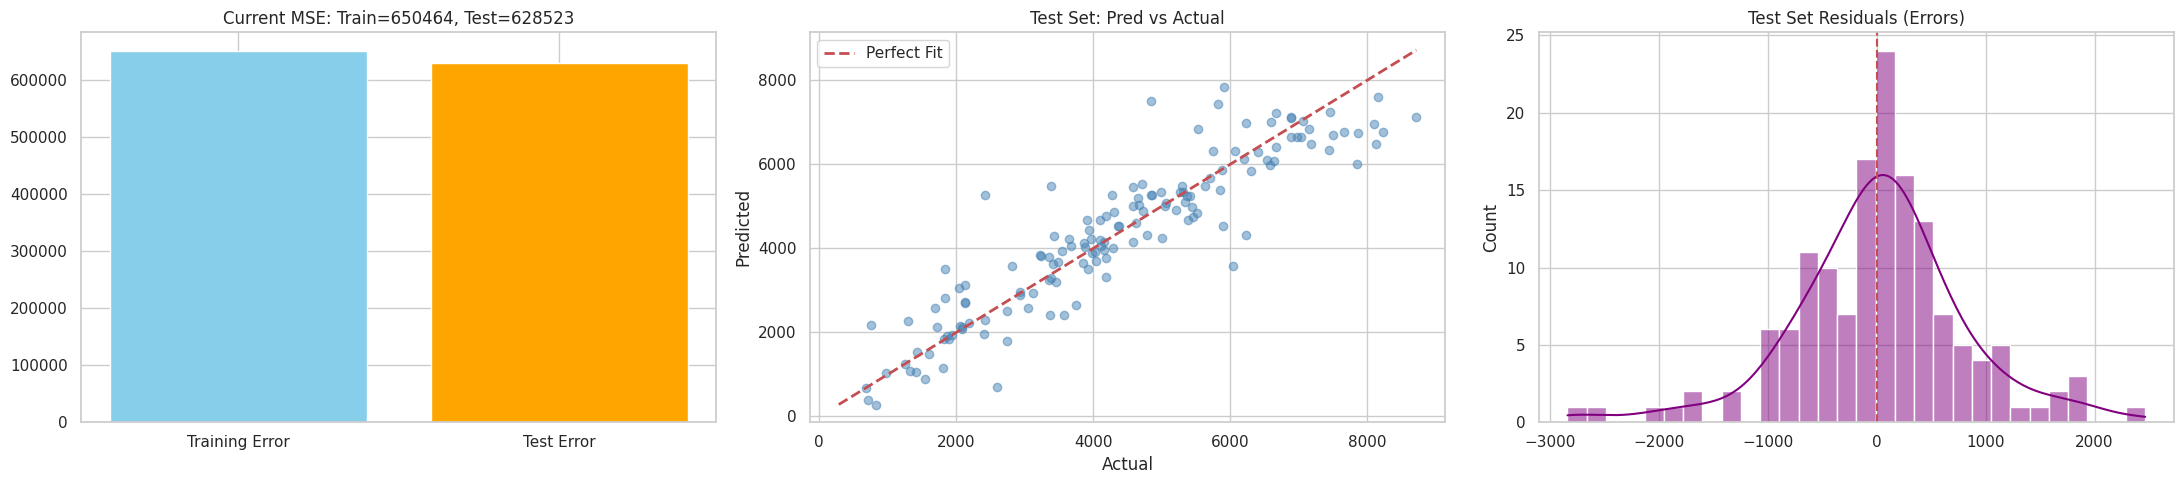

In [ ]:
# 1. Clean Copy
df_baseline = day_data_clean.copy()

print("Establishing Baseline...")
# 2. Run Helper and capture BOTH return values
base_train_mse, base_test_mse = test_feature_impact(df_baseline, "Baseline")

--- Results for: Humidity Squared ---
Training MSE: 639924.6198
Test MSE:     624222.5247
Train Improvement: +10539.8546
Test Improvement:  +4300.4091


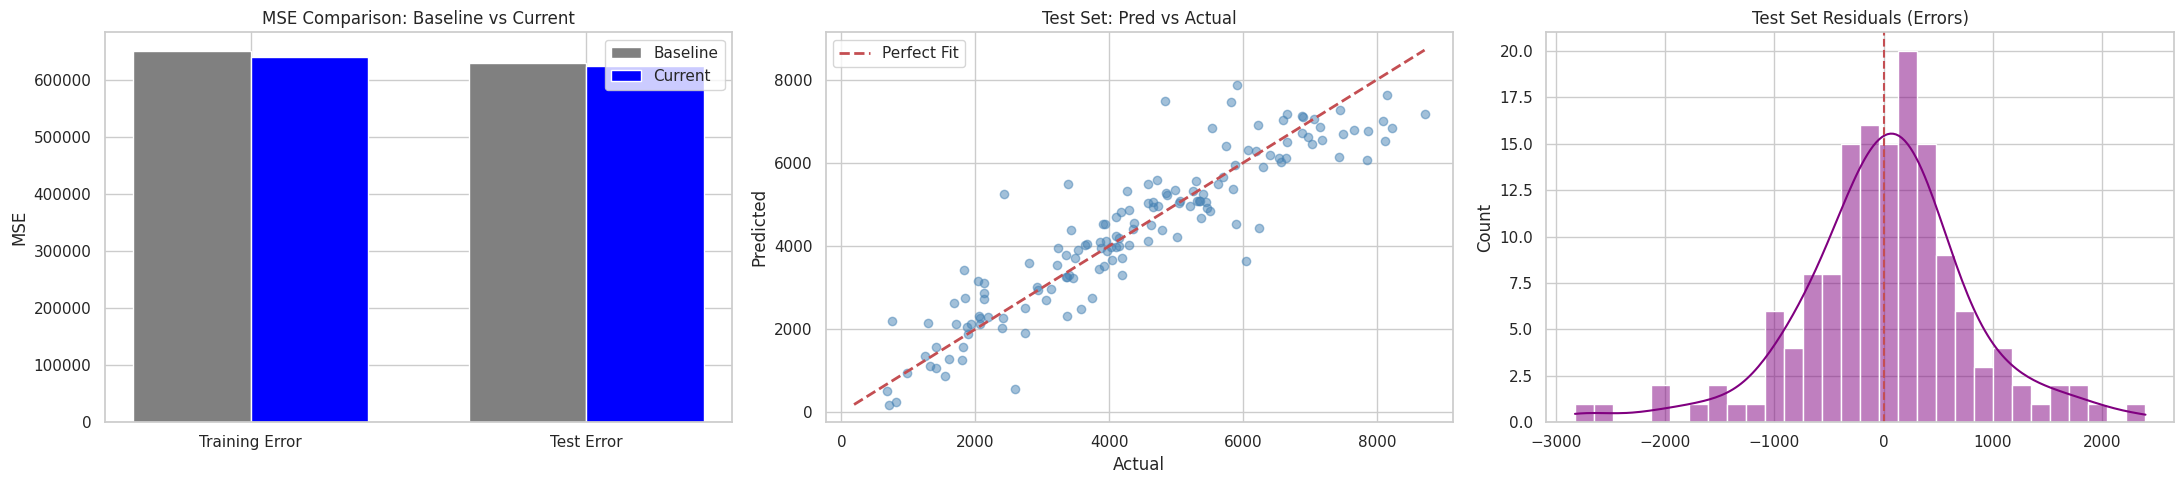

(np.float64(639924.6197890403), np.float64(624222.5246537554))

In [ ]:
df_hum = day_data_clean.copy()
df_hum['hum_sq'] = df_hum['hum'] ** 2

# Pass both baseline values for comparison
test_feature_impact(df_hum, "Humidity Squared", base_train_mse, base_test_mse)

--- Results for: Temp Squared ---
Training MSE: 565000.1877
Test MSE:     562281.8910
Train Improvement: +85464.2867
Test Improvement:  +66241.0427


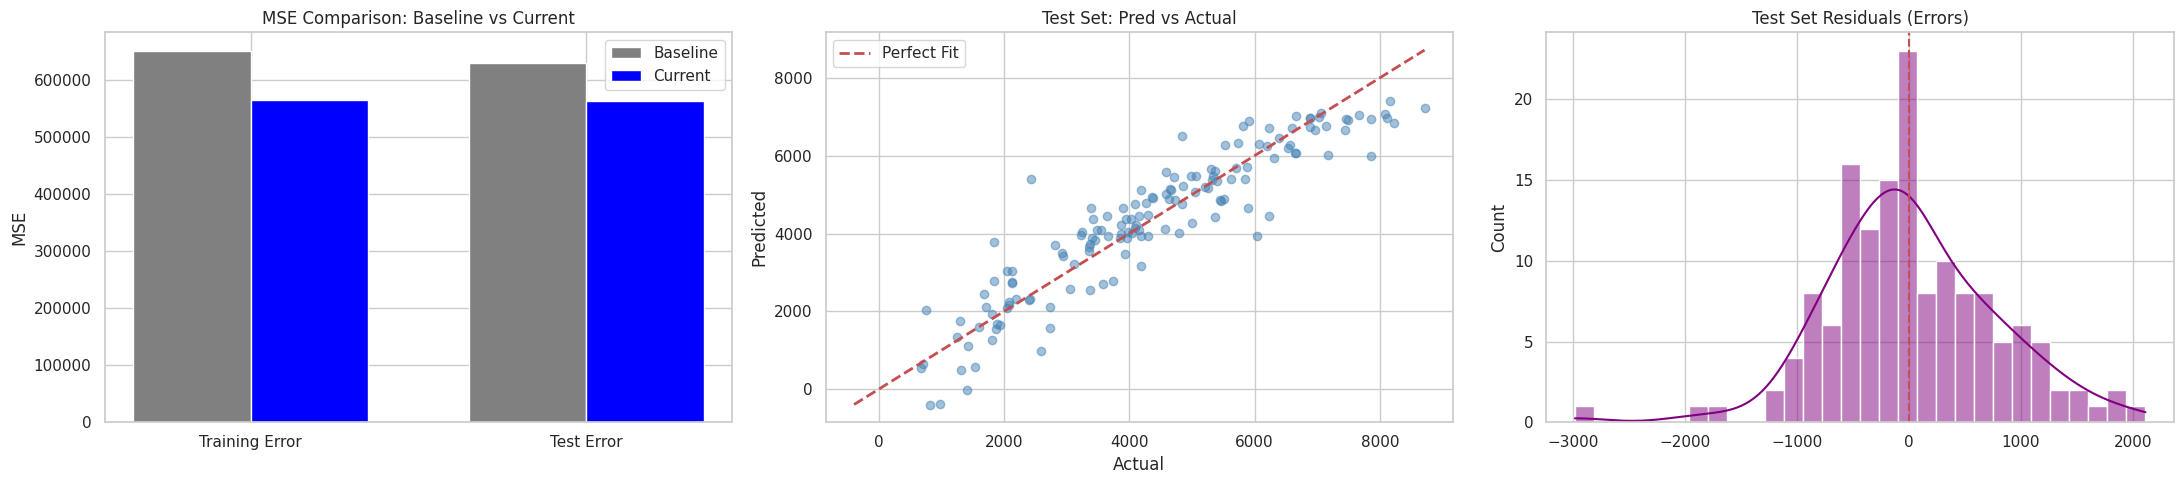

(np.float64(565000.187652158), np.float64(562281.8910145749))

In [ ]:
df_temp = day_data_clean.copy()
df_temp['temp_sq'] = (df_temp['temp'])** 2

test_feature_impact(df_temp, "Temp Squared", base_train_mse, base_test_mse)

--- Results for: Temp Cubed ---
Training MSE: 544713.1601
Test MSE:     525278.5186
Train Improvement: +105751.3143
Test Improvement:  +103244.4151


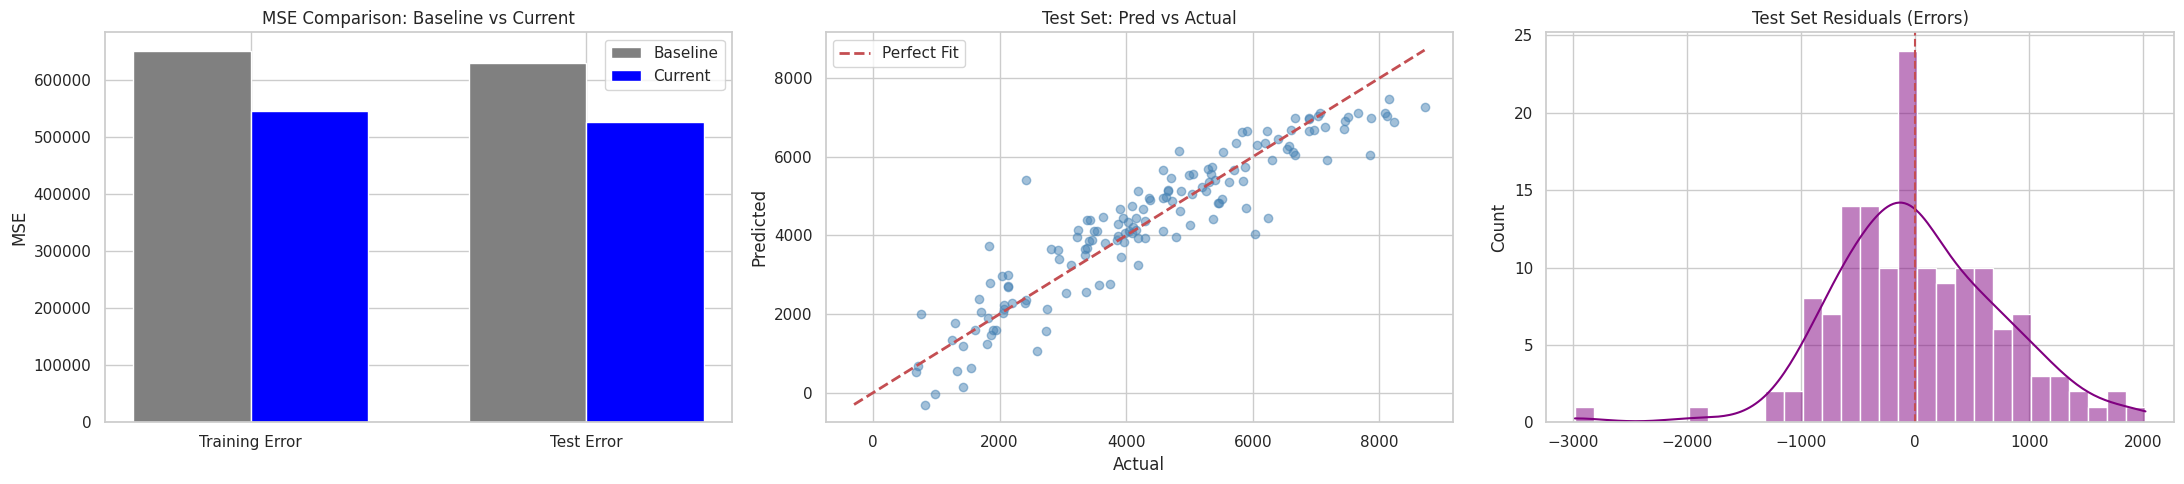

(np.float64(544713.1601094558), np.float64(525278.5186225484))

In [ ]:
df_temp_cub = day_data_clean.copy()
df_temp_cub['temp_cub'] = (df_temp['temp'])** 3

test_feature_impact(df_temp_cub, "Temp Cubed", base_train_mse, base_test_mse)

--- Results for: Wind Squared ---
Training MSE: 647203.3744
Test MSE:     628491.7090
Train Improvement: +3261.1000
Test Improvement:  +31.2247


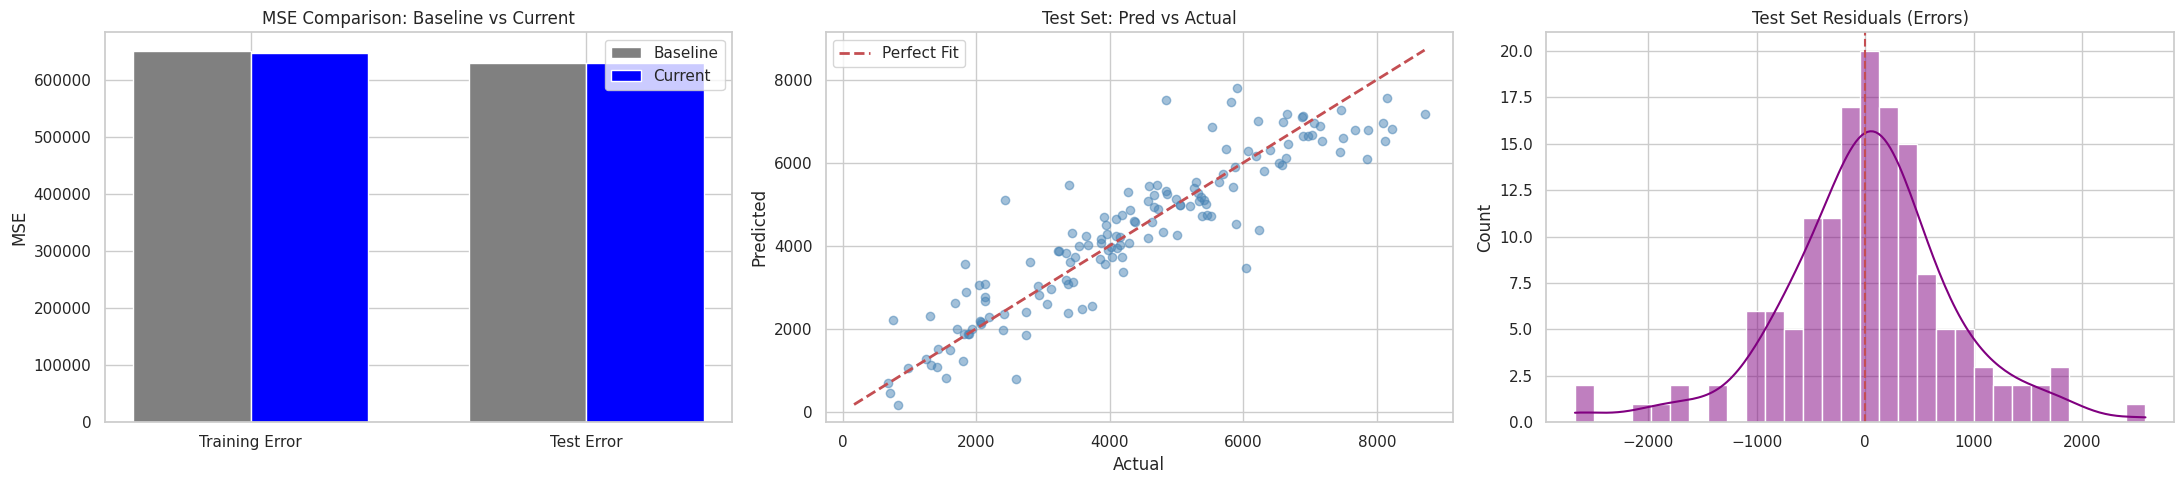

(np.float64(647203.3744028574), np.float64(628491.7090216688))

In [ ]:
df_wind = day_data_clean.copy()
df_wind['wind_sq'] = (df_wind['windspeed'])** 2

test_feature_impact(df_wind, "Wind Squared", base_train_mse, base_test_mse)

--- Results for: Interaction (Temp x Hum) ---
Training MSE: 626159.2318
Test MSE:     659514.3879
Train Improvement: +24305.2426
Test Improvement:  -30991.4541


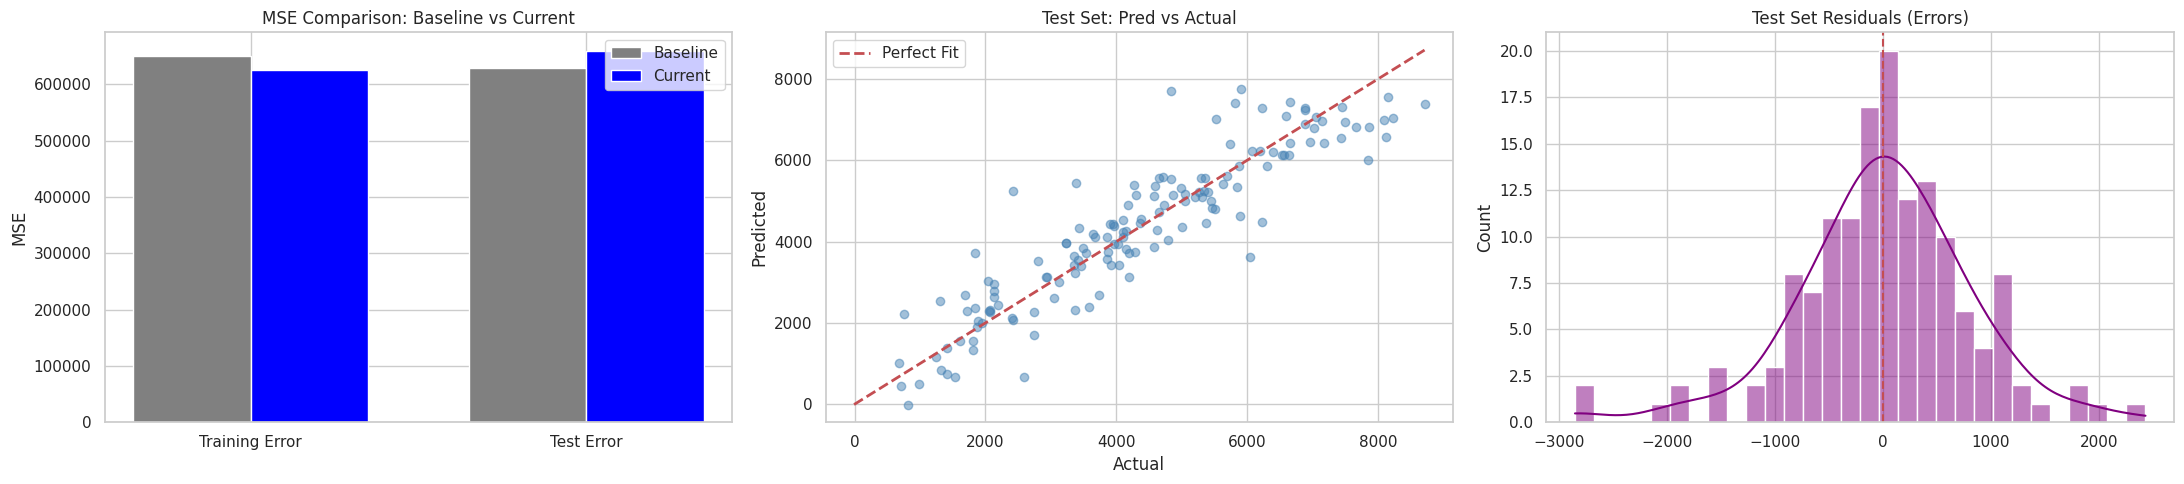

(np.float64(626159.2317725052), np.float64(659514.3878816692))

In [ ]:
df_inter = day_data_clean.copy()
df_inter['temp_x_hum'] = (df_inter['temp'] * df_inter['hum'])**2

test_feature_impact(df_inter, "Interaction (Temp x Hum)", base_train_mse, base_test_mse)

--- Results for: Log Temp ---
Training MSE: 579623.2250
Test MSE:     586712.3763
Train Improvement: +70841.2494
Test Improvement:  +41810.5575


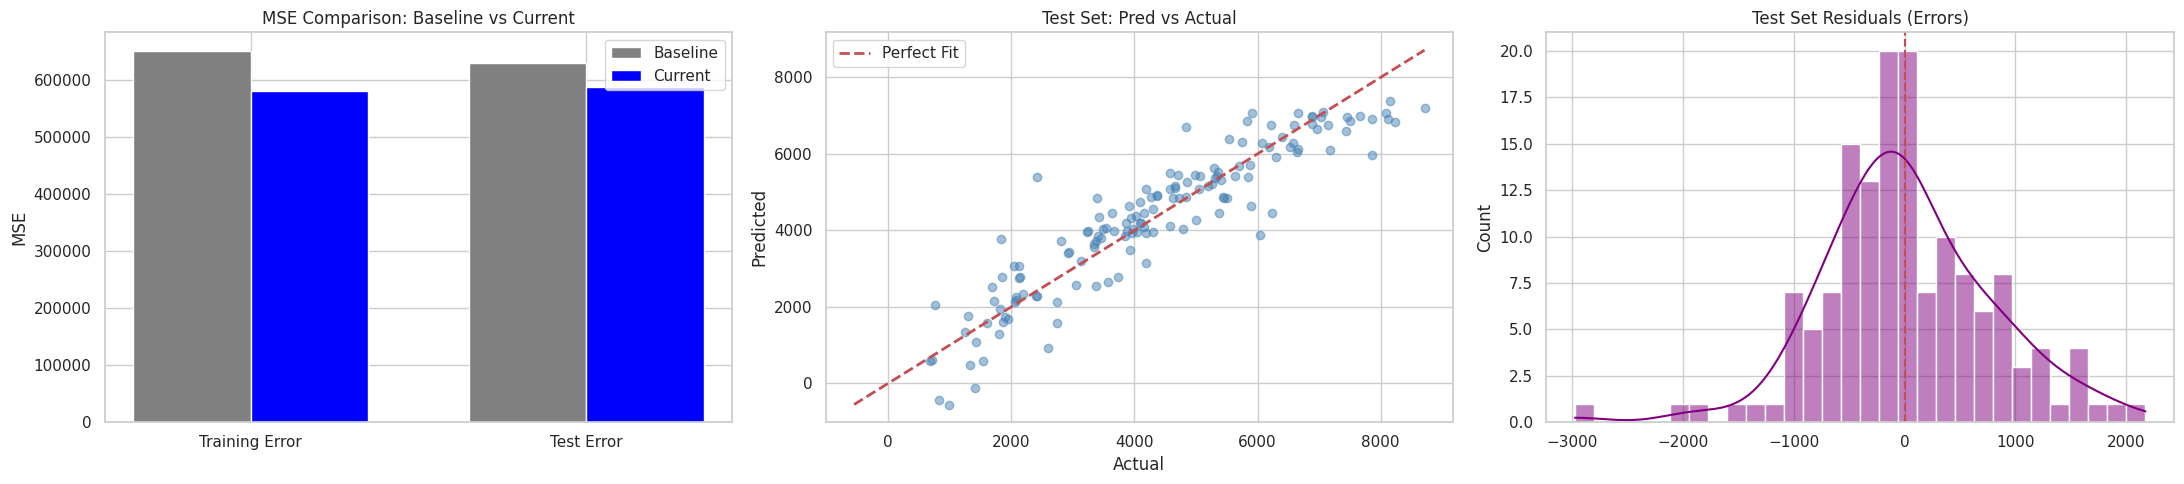

(np.float64(579623.2250302157), np.float64(586712.376269662))

In [ ]:
df_log = day_data_clean.copy()
df_log['log_temp'] = np.log1p(df_log['temp'])

test_feature_impact(df_log, "Log Temp", base_train_mse, base_test_mse)

--- Results for: Log Hum ---
Training MSE: 640233.8160
Test MSE:     623522.1134
Train Improvement: +10230.6584
Test Improvement:  +5000.8204


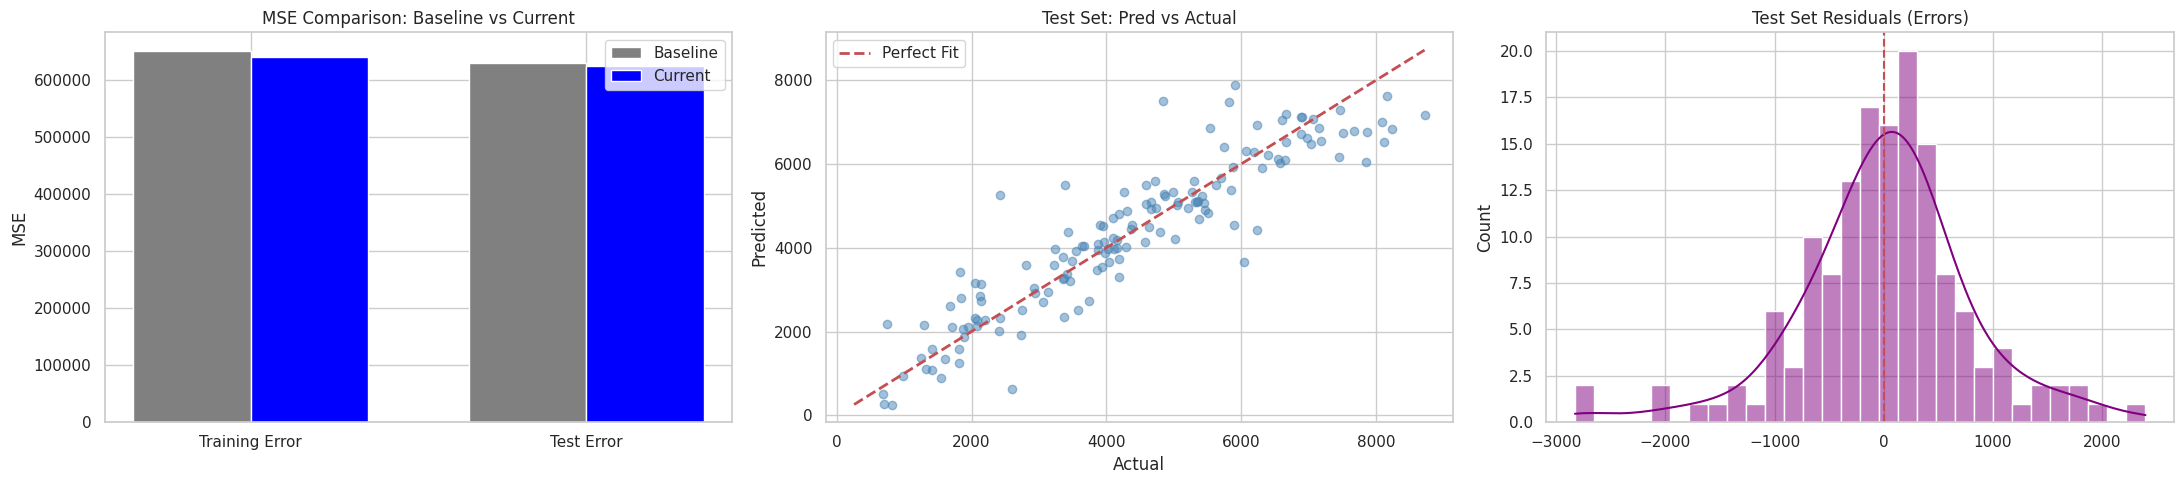

(np.float64(640233.8160277744), np.float64(623522.113403396))

In [ ]:
df_log_hum = day_data_clean.copy()
df_log_hum['log_hum'] = np.log1p(df_log['hum'])

test_feature_impact(df_log_hum, "Log Hum", base_train_mse, base_test_mse)

--- Results for: ALL Features ---
Training MSE: 489225.4054
Test MSE:     442661.9927
Train Improvement: +161239.0689
Test Improvement:  +185860.9411


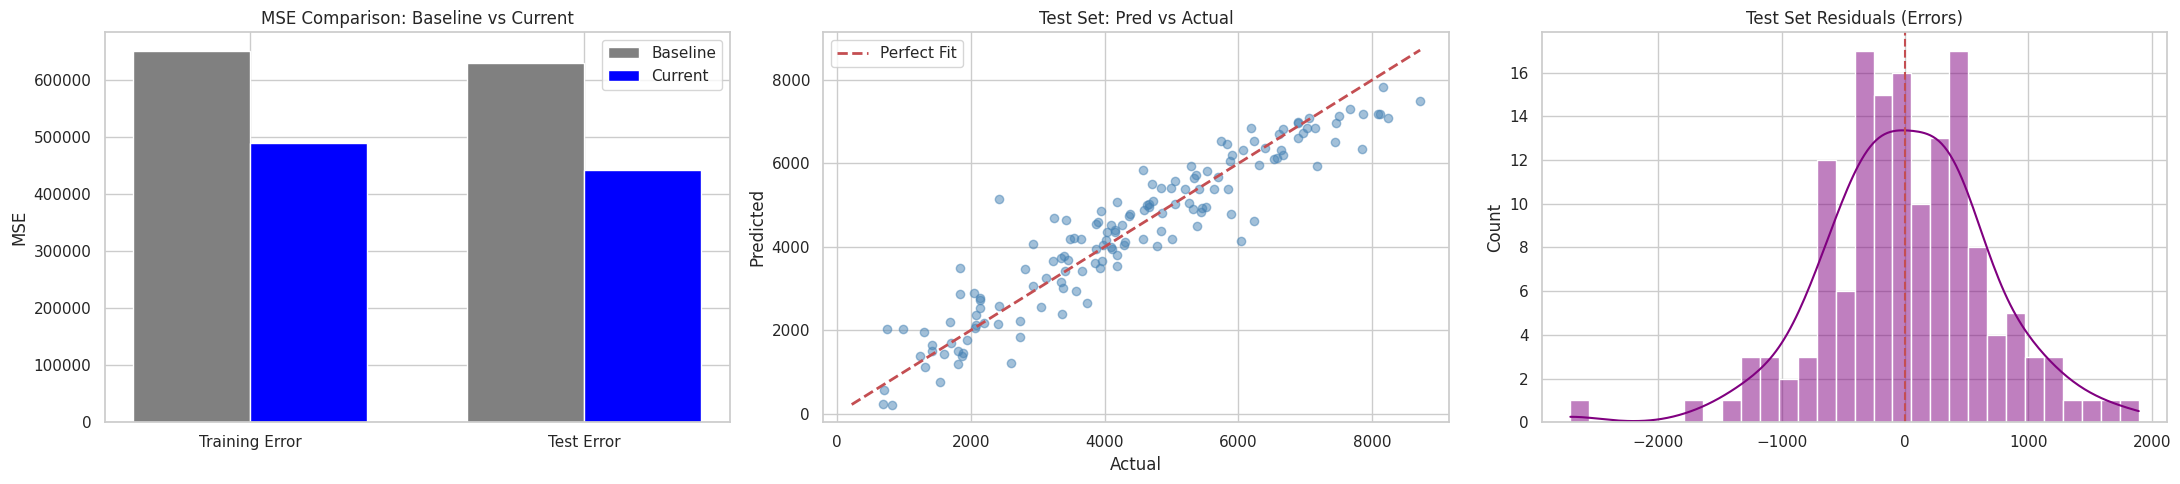


FINAL REPORT:
Total Test MSE Improvement: 185860.9411


In [ ]:
# 1. Combine all features that had inmprovement.
day_data_final = day_data_clean.copy()
day_data_final['hum_sq'] = day_data_final['hum'] ** 2
day_data_final['temp_sq'] = day_data_final['temp'] ** 2
day_data_final['temp_cub'] = day_data_final['temp'] ** 3
day_data_final['log_temp'] = np.log1p(day_data_final['temp'])
day_data_final['log_hum'] = np.log1p(day_data_final['hum'])
day_data_final['wind_sq'] = day_data_final['windspeed'] ** 2


# 2. Compare against Baseline
final_train, final_test = test_feature_impact(day_data_final, "ALL Features", base_train_mse, base_test_mse)

print("\nFINAL REPORT:")
print(f"Total Test MSE Improvement: {base_test_mse - final_test:.4f}")